# Test 3 — Adverse selection


This notebook try to answer to one question, does adding the adverse selection to the environnement change the decision problem or its just adding some noise ?



$$dS_t = \alpha_t\,dt + \sigma\,dW_t \qquad\text{et}\qquad
\lambda^{\text{sell}}(\alpha) = \lambda_0 e^{-\gamma\alpha}, \quad
\lambda^{\text{buy}}(\alpha) = \lambda_0 e^{+\gamma\alpha}$$

Quand $\alpha_t > 0$ le prix monte *et* les ordres de marché acheteurs deviennent plus fréquents — ils lèvent l'ask
du market maker, qui vend juste avant la hausse. L'adverse selection tombe de la structure, pas d'une hypothèse
ad hoc.

$\gamma = 0$ (`sensitivity=0`) redonne exactement `PoissonArrivalModel` : l'environnement enrichi **emboîte**
l'environnement à solution fermée, ce qui garde le benchmark analytique accessible comme cas limite.

**Plan** — 1. l'environnement · 2. vérification d'emboîtement · 3. le mécanisme · 4. l'adverse selection mesurée
(markout) · 5. inventaire conditionnel · 6. est-ce que la politique optimale change ?

In [1]:
import sys
sys.path.append("../src")  # This version of the notebook is in the subfolder "notebooks" of the repo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from agents.Agent import Agent
from agents.BaselineAgents import CarteaJaimungalMmAgent
from gym_local.ModelDynamics import LimitOrderModelDynamics
from gym_local.TradingEnvironment import TradingEnvironment
from gym_local.helpers.generate_trajectory import generate_trajectory
from gym_local.index_names import CASH_INDEX, INVENTORY_INDEX, ASSET_PRICE_INDEX
from rewards.RewardFunctions import CjMmCriterion, PnL
from stochastic_processes.arrival_models import PoissonArrivalModel, StateDependentPoissonArrivalModel
from stochastic_processes.fill_probability_models import ExponentialFillFunction
from stochastic_processes.midprice_models import OuMidpriceModel, ShortTermOuAlphaMidpriceModel

# Sensitivity is an ordered magnitude, so its series get a single-hue sequential ramp (light -> dark).
# Bid/ask is an identity pair, so it gets two distinct hues. Both were checked against the CVD, chroma and
# contrast gates rather than picked by eye.
RAMP = ["#7db2e6", "#4a90da", "#2a78d6", "#15406f"]
SELL_SIDE, BUY_SIDE = "#2a78d6", "#eb6834"
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.figsize": (7.2, 4.0), "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK, "axes.titlesize": 11,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


## 1. L'environnement

Un seul constructeur, paramétré par `sensitivity` ($\gamma$). Tout le reste est identique entre les deux régimes :
même midprice, même modèle de fill, mêmes intensités de base. C'est la condition pour que la comparaison isole
l'adverse selection et rien d'autre.

In [2]:
TERMINAL_TIME, N_STEPS = 1.0, 200
STEP_SIZE = TERMINAL_TIME / N_STEPS
ARRIVAL_RATE, FILL_EXPONENT, VOLATILITY = 140.0, 1.5, 2.0

# `OuMidpriceModel.update` applique sa reversion sans multiplier par le pas de temps : la vitesse par defaut de 1.0
# ecrase l'etat a chaque pas et laisse un bruit blanc. Une vitesse petite est ce qui donne un signal *persistant*,
# donc previsible -- c'est verifie dans la cellule suivante.
ALPHA_SPEED, ALPHA_VOLATILITY = 0.05, 20.0

# Avec ShortTermOuAlphaMidpriceModel en premier processus, l'etat vaut [cash, inventaire, temps, prix, alpha].
ALPHA_INDEX = 4


def get_env(sensitivity, num_trajectories, seed=101, max_inventory=20, reward_function=None,
            state_dependent=True):
    midprice_model = ShortTermOuAlphaMidpriceModel(
        volatility=VOLATILITY,
        ou_process=OuMidpriceModel(
            mean_reversion_level=0.0, mean_reversion_speed=ALPHA_SPEED, volatility=ALPHA_VOLATILITY,
            initial_price=0.0, terminal_time=TERMINAL_TIME, step_size=STEP_SIZE,
            num_trajectories=num_trajectories,
        ),
        initial_price=100.0, terminal_time=TERMINAL_TIME, step_size=STEP_SIZE,
        num_trajectories=num_trajectories,
    )
    intensity = np.array([ARRIVAL_RATE, ARRIVAL_RATE])
    arrival_model = (
        StateDependentPoissonArrivalModel(intensity, sensitivity, ALPHA_INDEX, STEP_SIZE, num_trajectories)
        if state_dependent
        else PoissonArrivalModel(intensity, STEP_SIZE, num_trajectories)
    )
    model_dynamics = LimitOrderModelDynamics(
        midprice_model=midprice_model, arrival_model=arrival_model,
        fill_probability_model=ExponentialFillFunction(FILL_EXPONENT, STEP_SIZE, num_trajectories),
        num_trajectories=num_trajectories,
    )
    env = TradingEnvironment(
        terminal_time=TERMINAL_TIME, n_steps=N_STEPS, model_dynamics=model_dynamics,
        num_trajectories=num_trajectories, max_inventory=max_inventory,
        reward_function=reward_function or PnL(),
        normalise_action_space=False, normalise_observation_space=False,
    )
    env.seed(seed)
    return env


class ConstantDepthAgent(Agent):
    # Profondeur fixe des deux cotes : aucune reaction a l'inventaire ni au signal, pour que ce qu'on mesure
    # vienne de l'environnement et non de la politique.
    def __init__(self, num_trajectories, depth=1 / FILL_EXPONENT):
        self.action = np.ones((num_trajectories, 2)) * depth

    def get_action(self, obs):
        return self.action


def rollout(sensitivity, num_trajectories, seed, **kwargs):
    env = get_env(sensitivity, num_trajectories, seed, **kwargs)
    observations, actions, rewards = generate_trajectory(env, ConstantDepthAgent(num_trajectories), seed=seed)
    return env, observations, actions, rewards

### Le signal est-il persistant ?

Un point qui décide de tout ce qui suit : de l'adverse selection **imprévisible** n'est que du bruit — elle
appauvrit tout le monde uniformément et laisse la solution fermée quasi optimale. Il n'y a quelque chose à
apprendre que si le facteur est à la fois observable et persistant.

In [3]:
rows = []
for speed, vol in [(1.0, 2.0), (0.05, 20.0), (0.02, 20.0)]:
    saved = ALPHA_SPEED, ALPHA_VOLATILITY
    ALPHA_SPEED, ALPHA_VOLATILITY = speed, vol
    _, observations, _, _ = rollout(0.0, num_trajectories=300, seed=7)
    ALPHA_SPEED, ALPHA_VOLATILITY = saved
    alpha = observations[:, ALPHA_INDEX, :]
    rows.append({
        "vitesse de reversion": speed, "volatilite alpha": vol,
        "ecart-type alpha": alpha.std(),
        "autocorrelation lag-1": np.corrcoef(alpha[:, :-1].ravel(), alpha[:, 1:].ravel())[0, 1],
    })
pd.DataFrame(rows).round(3)

,vitesse de reversion,volatilite alpha,ecart-type alpha,autocorrelation lag-1
0,1.00,2.0,0.142,-0.001
1,0.05,20.0,4.379,0.946
2,0.02,20.0,6.552,0.976


La première ligne est la configuration **par défaut** de `ShortTermOuAlphaMidpriceModel` : autocorrélation nulle,
c'est-à-dire un bruit blanc. Le « short term alpha » par défaut n'est donc pas un signal du tout. C'est une
conséquence de la discrétisation de `OuMidpriceModel`, qui applique $-\kappa(\alpha-\mu)$ sans facteur $dt$ ;
avec $\kappa = 1$ l'état est effacé à chaque pas.

On retient `mean_reversion_speed = 0.05`, qui donne une autocorrélation d'environ 0.95 : un signal réellement
prévisible. Le comportement par défaut est laissé intact et documenté dans
`testMidpriceModels.testOuMidpriceModelDiscretisation`.

## 2. Vérification d'emboîtement

Le contrôle le plus important du notebook, et il est falsifiable : à $\gamma = 0$ l'environnement enrichi doit
produire une trajectoire **identique bit à bit** à celle de `PoissonArrivalModel`, espace d'observation compris.
Si cette cellule échoue un jour, la comparaison de la section 6 n'a plus de sens.

In [4]:
for seed in (1, 55, 999, 12345):
    n = 30
    nested = generate_trajectory(get_env(0.0, n, seed, state_dependent=True), ConstantDepthAgent(n), seed=seed)
    baseline = generate_trajectory(get_env(0.0, n, seed, state_dependent=False), ConstantDepthAgent(n), seed=seed)
    identical = all(np.array_equal(a, b) for a, b in zip(nested, baseline))
    assert identical, f"nesting broken at seed {seed}"
    print(f"seed={seed:<6} trajectoires identiques : {identical}")
print("\nsensitivity = 0 redonne exactement PoissonArrivalModel.")

seed=1      trajectoires identiques : True
seed=55     trajectoires identiques : True
seed=999    trajectoires identiques : True
seed=12345  trajectoires identiques : True

sensitivity = 0 redonne exactement PoissonArrivalModel.


## 3. Le mécanisme : inclinaison des intensités

Ce que le modèle fait, avant de regarder ce qu'il produit. Le tilt est antisymétrique, donc la moyenne géométrique
des deux intensités ne bouge pas : le signal redistribue le flux entre les deux côtés du carnet sans changer son
volume total.

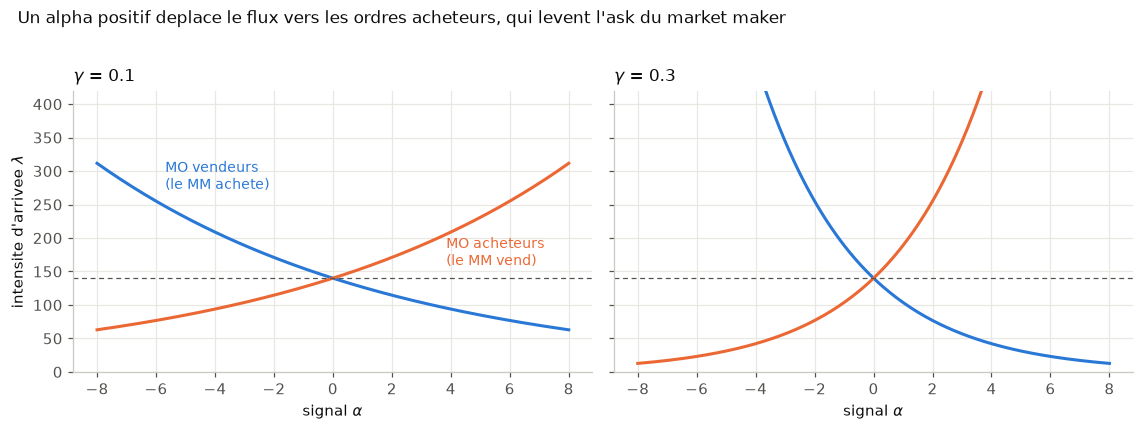

In [5]:
alpha_grid = np.linspace(-8, 8, 201)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)

for ax, sensitivity in zip(axes, (0.1, 0.3)):
    model = StateDependentPoissonArrivalModel(
        np.array([ARRIVAL_RATE, ARRIVAL_RATE]), sensitivity, ALPHA_INDEX, STEP_SIZE, len(alpha_grid))
    state = np.zeros((len(alpha_grid), 5))
    state[:, ALPHA_INDEX] = alpha_grid
    intensities = model.get_intensities(state)
    ax.plot(alpha_grid, intensities[:, 0], color=SELL_SIDE)
    ax.plot(alpha_grid, intensities[:, 1], color=BUY_SIDE)
    ax.axhline(ARRIVAL_RATE, color=MUTED, linewidth=0.8, linestyle=(0, (4, 3)))
    ax.set_title(f"$\\gamma$ = {sensitivity}", loc="left")
    ax.set_xlabel("signal $\\alpha$")
    ax.annotate("MO vendeurs\n(le MM achete)", (alpha_grid[25], intensities[25, 0]), color=SELL_SIDE,
                fontsize=9, xytext=(6, 8), textcoords="offset points")
    ax.annotate("MO acheteurs\n(le MM vend)", (alpha_grid[-40], intensities[-40, 1]), color=BUY_SIDE,
                fontsize=9, xytext=(-20, -30), textcoords="offset points")

axes[0].set_ylabel("intensite d'arrivee $\\lambda$")
axes[0].set_ylim(0, 3 * ARRIVAL_RATE)
fig.suptitle("Un alpha positif deplace le flux vers les ordres acheteurs, qui levent l'ask du market maker",
             y=1.02, x=0.02, ha="left", fontsize=11)
plt.tight_layout()

## 4. L'adverse selection mesurée : la courbe de markout

Le markout est la signature empirique de l'adverse selection, et c'est ce que mesurent les praticiens :

$$m_h \;=\; \mathbb{E}\big[\Delta q_t \cdot (S_{t+h} - S_t)\big]$$

où $\Delta q_t$ est la variation d'inventaire du market maker sur $[t, t+1]$. **Négatif = le prix bouge contre la
position qu'on vient de prendre.**

Ce vecteur $(m_h)_h$ est aussi le vecteur de moments naturel pour une calibration par méthode des moments simulés :
il suridentifie largement le paramètre $\gamma$, ce qui rend le test de suridentification disponible comme test de
spécification.

In [6]:
HORIZONS = (1, 2, 5, 10, 20, 50)
SENSITIVITIES = (0.0, 0.1, 0.2, 0.4)
SEEDS = (11, 22, 33, 44, 55)


def get_markouts(observations, horizons=HORIZONS):
    inventory_change = np.diff(observations[:, INVENTORY_INDEX, :], axis=1)
    price = observations[:, ASSET_PRICE_INDEX, :]
    n_usable = inventory_change.shape[1]
    return {h: float(np.mean(inventory_change[:, : n_usable - h]
                             * (price[:, h : h + n_usable - h] - price[:, : n_usable - h])))
            for h in horizons}


markout_runs = {
    sensitivity: pd.DataFrame([get_markouts(rollout(sensitivity, 500, seed)[1]) for seed in SEEDS], index=SEEDS)
    for sensitivity in SENSITIVITIES
}
markout_mean = pd.DataFrame({s: df.mean() for s, df in markout_runs.items()})
markout_se = pd.DataFrame({s: df.std(ddof=1) / np.sqrt(len(SEEDS)) for s, df in markout_runs.items()})
markout_mean.rename_axis("horizon h", axis=0).rename_axis("gamma", axis=1).round(5)

gamma,0.0,0.1,0.2,0.4
horizon h,,,,
1,-0.00023,-0.00354,-0.00434,-0.00492
2,-0.00016,-0.00661,-0.00829,-0.00939
5,-0.00040,-0.01514,-0.01908,-0.02175
10,-0.00044,-0.02684,-0.03380,-0.03878
20,-0.00005,-0.04267,-0.05379,-0.06245
50,0.00056,-0.06206,-0.07881,-0.09156


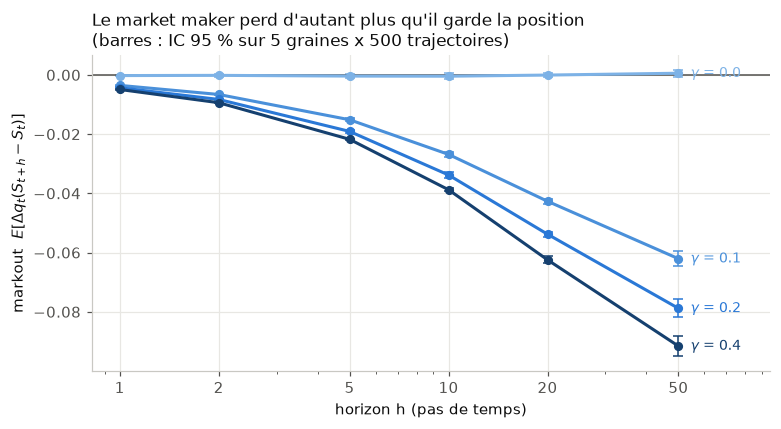

In [7]:
fig, ax = plt.subplots()
for colour, sensitivity in zip(RAMP, SENSITIVITIES):
    mean, se = markout_mean[sensitivity], markout_se[sensitivity]
    ax.errorbar(HORIZONS, mean, yerr=1.96 * se, color=colour, marker="o", markersize=5,
                capsize=3, elinewidth=1, label=f"$\\gamma$ = {sensitivity}")
    ax.annotate(f"$\\gamma$ = {sensitivity}", (HORIZONS[-1], mean.iloc[-1]), color=colour, fontsize=9,
                xytext=(8, -3), textcoords="offset points")

ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xscale("log")
ax.set_xticks(HORIZONS)
ax.set_xticklabels(HORIZONS)
ax.set_xlabel("horizon h (pas de temps)")
ax.set_ylabel("markout  $E[\\Delta q_t (S_{t+h} - S_t)]$")
ax.set_title("Le market maker perd d'autant plus qu'il garde la position\n"
             "(barres : IC 95 % sur 5 graines x 500 trajectoires)", loc="left")
ax.set_xlim(right=95)
plt.tight_layout()

Trois choses à lire ici.

1. **À $\gamma = 0$ la courbe est plate sur zéro.** C'est le contrôle : sans le facteur partagé, les exécutions
   sont indépendantes des mouvements de prix ultérieurs. Les valeurs restent au niveau de $5\cdot 10^{-4}$, deux
   ordres de grandeur sous l'effet à $\gamma > 0$, et changent de signe d'un tirage à l'autre. À $h = 50$
   l'estimateur devient asymétrique et bruité — sur 20 graines sa moyenne vaut $-0.0015$ avec $t = -3.2$, mais
   cette statistique n'est pas fiable vu l'asymétrie. Le test unitaire compare donc les deux régimes par un rapport
   plutôt que de fixer un seuil absolu.
2. **La courbe décroît avec l'horizon.** C'est la forme observée sur données réelles : l'adverse selection
   s'accumule tant que la position est portée.
3. **Elle est monotone en $\gamma$ et sature.** Passer de 0.2 à 0.4 double le paramètre mais n'ajoute qu'environ
   20 % de markout — le tilt sature parce que la probabilité d'arrivée est bornée.

## 5. Inventaire conditionnel au signal

Le markout est un agrégat. Voici le mécanisme vu directement : quel inventaire le market maker accumule-t-il
selon la valeur du signal ?

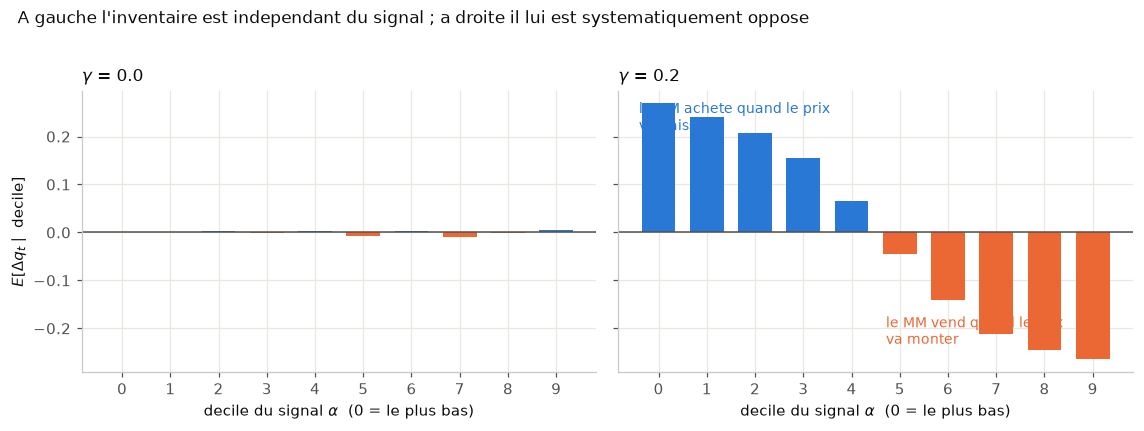

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
deciles = np.arange(10)

for ax, sensitivity in zip(axes, (0.0, 0.2)):
    _, observations, _, _ = rollout(sensitivity, 600, seed=101)
    alpha = observations[:, ALPHA_INDEX, :-1].ravel()
    inventory_change = np.diff(observations[:, INVENTORY_INDEX, :], axis=1).ravel()
    edges = np.quantile(alpha, np.linspace(0, 1, 11))
    bucket = np.clip(np.digitize(alpha, edges[1:-1]), 0, 9)
    means = np.array([inventory_change[bucket == d].mean() for d in deciles])
    ax.bar(deciles, means, color=[SELL_SIDE if m >= 0 else BUY_SIDE for m in means], width=0.7)
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.set_title(f"$\\gamma$ = {sensitivity}", loc="left")
    ax.set_xlabel("decile du signal $\\alpha$  (0 = le plus bas)")
    ax.set_xticks(deciles)

axes[0].set_ylabel("$E[\\Delta q_t \\mid$ decile$]$")
axes[1].annotate("le MM achete quand le prix\nva baisser", (0.04, 0.86), xycoords="axes fraction",
                 color=SELL_SIDE, fontsize=9)
axes[1].annotate("le MM vend quand le prix\nva monter", (0.52, 0.10), xycoords="axes fraction",
                 color=BUY_SIDE, fontsize=9)
fig.suptitle("A gauche l'inventaire est independant du signal ; a droite il lui est systematiquement oppose",
             y=1.02, x=0.02, ha="left", fontsize=11)
plt.tight_layout()

## 6. Est-ce que la politique optimale change ?

C'est la question qui décide si le facteur mérite d'être dans l'environnement. Un facteur peut être massivement
significatif dans les données et laisser la politique optimale inchangée — auquel cas on peut s'en passer.

On déploie donc l'agent Cartea–Jaimungal en forme fermée, **inchangé**, dans les deux environnements, sur les mêmes
trajectoires d'évaluation (comparaison appariée).

> Attention à ce que ce bras mesure. C'est le **CF-naïf** : ses paramètres viennent de $E_\text{closed}$ et il ne
> voit pas $\alpha$. Il mesure le coût de la mauvaise spécification, pas la supériorité du RL. Le benchmark
> honnête pour un futur agent RL est le **CF-recalibré** — mêmes formules, paramètres réajustés pour être la
> meilleure politique CJ *dans* $E_\text{rich}$. C'est la couche suivante.

In [9]:
reward_function = CjMmCriterion(per_step_inventory_aversion=0.01, terminal_inventory_aversion=1.0,
                                terminal_time=TERMINAL_TIME)
rows = []
for seed in (13, 77, 404):
    for sensitivity, label in ((0.0, "E_closed  (gamma = 0)"), (0.2, "E_rich    (gamma = 0.2)")):
        env = get_env(sensitivity, 2000, seed=seed, reward_function=reward_function)
        observations, _, _ = generate_trajectory(env, CarteaJaimungalMmAgent(env=env), seed=seed)
        terminal_pnl = observations[:, CASH_INDEX, -1] + observations[:, INVENTORY_INDEX, -1] * observations[:, ASSET_PRICE_INDEX, -1]
        rows.append({"graine": seed, "environnement": label, "PnL moyen": terminal_pnl.mean(),
                     "ecart-type PnL": terminal_pnl.std(),
                     "|inventaire terminal|": np.abs(observations[:, INVENTORY_INDEX, -1]).mean()})

results = pd.DataFrame(rows)
results.groupby("environnement")[["PnL moyen", "ecart-type PnL", "|inventaire terminal|"]].mean().round(2)

,PnL moyen,ecart-type PnL,|inventaire terminal|
environnement,,,
E_closed (gamma = 0),67.49,10.16,0.39
E_rich (gamma = 0.2),48.39,21.42,1.90


In [10]:
closed, rich = (results[results.environnement.str.startswith(p)] for p in ("E_closed", "E_rich"))
print("Comparaison appariee, agent Cartea-Jaimungal en forme fermee, 3 graines x 2000 trajectoires\n")
for seed, a, b in zip(closed.graine, closed["PnL moyen"], rich["PnL moyen"]):
    print(f"  graine {seed:<5} PnL {a:+7.2f} -> {b:+7.2f}   ({100 * (b - a) / a:+.1f} %)")
print(f"\n  PnL moyen        : {100 * (rich['PnL moyen'].mean() / closed['PnL moyen'].mean() - 1):+.1f} %")
print(f"  volatilite du PnL: x{rich['ecart-type PnL'].mean() / closed['ecart-type PnL'].mean():.2f}")
print(f"  inventaire porte : x{rich['|inventaire terminal|'].mean() / closed['|inventaire terminal|'].mean():.2f}")

Comparaison appariee, agent Cartea-Jaimungal en forme fermee, 3 graines x 2000 trajectoires

  graine 13    PnL  +67.40 ->  +48.32   (-28.3 %)
  graine 77    PnL  +67.27 ->  +48.12   (-28.5 %)
  graine 404   PnL  +67.80 ->  +48.73   (-28.1 %)

  PnL moyen        : -28.3 %
  volatilite du PnL: x2.11
  inventaire porte : x4.84


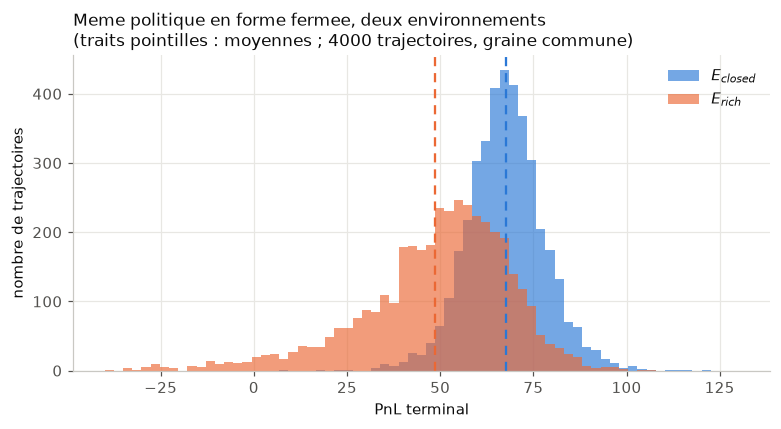

In [11]:
fig, ax = plt.subplots()
bins = np.linspace(-40, 130, 70)
for colour, sensitivity, label in ((SELL_SIDE, 0.0, "$E_{closed}$"), (BUY_SIDE, 0.2, "$E_{rich}$")):
    env = get_env(sensitivity, 4000, seed=13, reward_function=reward_function)
    observations, _, _ = generate_trajectory(env, CarteaJaimungalMmAgent(env=env), seed=13)
    terminal_pnl = observations[:, CASH_INDEX, -1] + observations[:, INVENTORY_INDEX, -1] * observations[:, ASSET_PRICE_INDEX, -1]
    ax.hist(terminal_pnl, bins=bins, color=colour, alpha=0.65, label=label)
    ax.axvline(terminal_pnl.mean(), color=colour, linewidth=1.5, linestyle=(0, (4, 3)))

ax.set_xlabel("PnL terminal")
ax.set_ylabel("nombre de trajectoires")
ax.set_title("Meme politique en forme fermee, deux environnements\n"
             "(traits pointilles : moyennes ; 4000 trajectoires, graine commune)", loc="left")
ax.legend()
plt.tight_layout()

## Ce que ce notebook établit, et ce qu'il n'établit pas

**Établi.**

| Résultat | Mesure |
|---|---|
| L'environnement enrichi emboîte l'ancien | trajectoires identiques bit à bit à $\gamma = 0$, sur 4 graines |
| Le mécanisme produit bien de l'adverse selection | markout négatif, décroissant en $h$, monotone en $\gamma$, IC 95 % disjoints de zéro |
| L'adverse selection est prévisible, pas du bruit | $\alpha$ observable, autocorrélation lag-1 ≈ 0.95, inventaire opposé au signal décile par décile |
| **Le facteur change le problème de décision** | la politique CJ inchangée perd ≈ 28 % de PnL moyen et double sa volatilité, stable sur 3 graines |

Le dernier point est celui qui justifie d'ajouter le facteur : il n'est pas seulement présent, il déplace
l'optimum. Un facteur qui laisserait ces trois colonnes inchangées pourrait être omis sans coût.

**Non établi — les couches suivantes.**

1. **Le bras CF-recalibré.** Tout ce qu'on a montré, c'est qu'une politique mal spécifiée souffre. Il faut la
   meilleure politique CJ *dans* $E_\text{rich}$ avant de pouvoir attribuer quoi que ce soit à un agent RL.
2. **La calibration sur données réelles.** $\gamma = 0.2$ est arbitraire. La courbe de markout de la section 4 est
   le vecteur de moments ; le calibrer par SMM sur des markouts empiriques, et lire le test de suridentification,
   transformerait « le mécanisme existe » en « le mécanisme reproduit les données ».
3. **Le couplage côté fill.** Les signatures `get_fills(depths, state)` et `_get_fill_probabilities(depths, state)`
   reçoivent déjà l'état ; aucun modèle ne s'en sert encore. Un $\kappa(\alpha)$ ajouterait une seconde voie
   d'adverse selection.
4. **Les agents RL.** L'environnement expose $\alpha$ dans l'observation, donc un agent peut apprendre à s'en
   servir. C'est l'objet du test suivant.